# Hematopoietic differentiation

Hematopoietic stem cells (HSC) are a special kind of undifferentiated tissue residing in bone marrow that our bodies use to continuously replenish red and white blood cells, because blood cells cannot reproduce naturally. This has several advantages: Cells that don't reproduce are more efficient, less prone to mutation and damage, and having a central production factory for all blood cells allows additional "quality control" and regulation of the whole process. However, this architecture also has disadvantages, because diseases that target bone marrow and HSCs can have outsized impact on the whole organism (e.g. leukaemia).

However, HSCs are not a homogenous population; They typically maintain several different phenotypes throughout the population which allow them to maintain a steady state and prevent premature differentiation.

In this tutorial, we will largely try to explain (with necessary oversimplifications) the process of the following two papers:

 - Hérault, Léonard, et al. "Single-cell RNA-seq reveals a concomitant delay in differentiation and cell cycle of aged hematopoietic stem cells." BMC biology 19.1 (2021): 19.
 - Hérault, Léonard, et al. "A novel Boolean network inference strategy to model early hematopoiesis aging." Computational and Structural Biotechnology Journal 21 (2023): 21-33.

These papers cover a large study of HSCs in aging mice by studing their RNA expression. Specifically, four smaller datasets were collected **two young and two aged** replicas.

In this research, the team identified several interesting sub-populations of HSCs, divided into two groups: First group are the "lineage-primed" HSCs. These are not fully differentiated yet, but exhibit some of the initial gene expression patterns that commit them to a specific future cell type. In particular, these include:

 - `pMk` | primed megakaryocytes (future bone marrow cells that produce thromobcytes; blood platelets).
 - `pEr` | primed erythroids (future red blood cells).
 - `pNeuMast` | primed neutrophils and mastocytes (future white blood cells). Technically, these are two distinct sub-categories, but the dataset does not provide enough resolution to tell them reliably apart, so the authors put them in a single group.
 - `pLymph` | primed lymphocytes (third major category of white blood cells identified in the data).

Second large category were the actual HSCs. Here, the authors again identified five categories. This time they are to some extent based on gene expression related to different phases of the cell cycle:

 - `preDiff` | pre-differentiation cells; A category of HSCs that show some signs of commitment towards the categories defined above, but are not yet fully committed.
 - `srHSC` | self-renewing HSCs; Currently in the G2/M cell cycle phase (undergoing division).
 - `iHSC` | initiaitng HSCs; Not in the G2/M phase, but also not showing any active signalling reaction (see below).
 - `qHSC` | quiescent HSCs; Currently in the dormant G0/G1 cell cycle phases enforced by TGF signaling.
 - `ifnHSC` | interferon HSCs; Currently still in the G0/G1 cell cycle phases, but "primed" for future activity by Interferon signaling.

Finally, authors tried to place these cell states onto a "pseudotime trajectory" (see below). This orders cells not necessarily by absolute time, but by their "closeness" and can often reveal differentiation trends. *Pseudotime alone is not very precise or definitive*, but can be a useful starting point for future research, especially if some of the cell phenotypes are already known.

<img src="pseudotime.png" alt="Pseudotime figure by Herault et al." width="400"/>

## Data preparation

We will not have enough time to cover how all of these cell phenotypes and pseudotime ordering were derived from data (some parts will be covered in the second week). However, we can take advantage of the already published results to have a look at how is this dataset structured.

In [1]:
# First, we download the four datasets and place them in single folder:

!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443875/suppl/GSM4443875_young_A_barcodes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443875/suppl/GSM4443875_young_A_genes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443875/suppl/GSM4443875_young_A_matrix.mtx.gz"

!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443876/suppl/GSM4443876_young_B_barcodes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443876/suppl/GSM4443876_young_B_genes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443876/suppl/GSM4443876_young_B_matrix.mtx.gz"

!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443877/suppl/GSM4443877_old_A_barcodes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443877/suppl/GSM4443877_old_A_genes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443877/suppl/GSM4443877_old_A_matrix.mtx.gz"

!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443878/suppl/GSM4443878_old_B_barcodes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443878/suppl/GSM4443878_old_B_genes.tsv.gz"
!wget -nc "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443878/suppl/GSM4443878_old_B_matrix.mtx.gz"

!mkdir -p data/young_A
!mkdir -p data/young_B
!mkdir -p data/old_A
!mkdir -p data/old_B

!mv GSM4443875_young_A_barcodes.tsv.gz ./data/young_A/barcodes.tsv.gz
!mv GSM4443875_young_A_genes.tsv.gz ./data/young_A/genes.tsv.gz
!mv GSM4443875_young_A_matrix.mtx.gz ./data/young_A/matrix.mtx.gz

!mv GSM4443876_young_B_barcodes.tsv.gz ./data/young_B/barcodes.tsv.gz
!mv GSM4443876_young_B_genes.tsv.gz ./data/young_B/genes.tsv.gz
!mv GSM4443876_young_B_matrix.mtx.gz ./data/young_B/matrix.mtx.gz

!mv GSM4443877_old_A_barcodes.tsv.gz ./data/old_A/barcodes.tsv.gz
!mv GSM4443877_old_A_genes.tsv.gz ./data/old_A/genes.tsv.gz
!mv GSM4443877_old_A_matrix.mtx.gz ./data/old_A/matrix.mtx.gz

!mv GSM4443878_old_B_barcodes.tsv.gz ./data/old_B/barcodes.tsv.gz
!mv GSM4443878_old_B_genes.tsv.gz ./data/old_B/genes.tsv.gz
!mv GSM4443878_old_B_matrix.mtx.gz ./data/old_B/matrix.mtx.gz

--2026-07-12 16:22:52--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4443nnn/GSM4443875/suppl/GSM4443875_young_A_barcodes.tsv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 

130.14.250.13, 130.14.250.31, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... 

connected.


HTTP request sent, awaiting response... 

200 OK
Length: 22381 (22K) [application/x-gzip]
Saving to: ‘GSM4443875_young_A_barcodes.tsv.gz’

          GSM444387   0%[                    ]       0  --.-KB/s               

...

  GSM4443878_old_B_  54%[=========>          ]  16.91M  9.69MB/s               

 GSM4443878_old_B_m  64%[===========>        ]  20.01M  10.2MB/s               

GSM4443878_old_B_ma  75%[==============>     ]  23.21M  10.8MB/s               

SM4443878_old_B_mat  85%[================>   ]  26.47M  11.2MB/s               

GSM4443878_old_B_ma 100%[===================>]  30.85M  12.0MB/s    in 2.6s    

2026-07-12 16:23:12 (12.0 MB/s) - ‘GSM4443878_old_B_matrix.mtx.gz’ saved [32346929/32346929]



In [2]:
# Also download the cell type annotations produced by the authors of the dataset:

!wget -nc https://github.com/leonardHerault/scRNA_infer/raw/refs/heads/master/report/tables/sc_metadata.csv
!mv sc_metadata.csv data/annotations.csv

--2026-07-12 16:23:15--  https://github.com/leonardHerault/scRNA_infer/raw/refs/heads/master/report/tables/sc_metadata.csv
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... 

connected.
HTTP request sent, awaiting response... 

302 Found
Location: https://raw.githubusercontent.com/leonardHerault/scRNA_infer/refs/heads/master/report/tables/sc_metadata.csv [following]
--2026-07-12 16:23:16--  https://raw.githubusercontent.com/leonardHerault/scRNA_infer/refs/heads/master/report/tables/sc_metadata.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 7283591 (6.9M) [text/plain]
Saving to: ‘sc_metadata.csv’

sc_metadata.csv       0%[                    ]       0  --.-KB/s               

sc_metadata.csv     100%[===================>]   6.95M  --.-KB/s    in 0.1s    

2026-07-12 16:23:16 (71.5 MB/s) - ‘sc_metadata.csv’ saved [7283591/7283591]



In [3]:
# Next, we import the relevant tools. Most important are `anndata` and `scanpy`. 
# The rest is mostly for some visualization and utility functions.
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy.io

Single cell RNA data is typically manipulated in a multi-dimensional matrix using the package `anndata`. Aside from the main "dimensions" (genes and cells/barcodes), the anndata matrix can also contain additional "observation dimensions" which add metadata to each cell/barcode. There can be also additional metadata stored in such a matrix (e.g. raw and noramlized RNA counts), but we will not need that many advanced features of `anndata` for this tutorial.


Here, our main goal is to load all four datasets and merge them into one large table. Because the barcodes may not be unique across datasets, we add the group id to each barcode to ensure uniqueness.


In [4]:
# Define the groups and their folder locations
groups = ['young_A', 'young_B', 'old_A', 'old_B']
adatas = []

for group in groups:
    print(f"Loading group: {group}")
    data_dir = f'data/{group}/'  # e.g., 'data/young_A/'
    
    # 1. Load the sparse matrix
    X = scipy.io.mmread(data_dir + 'matrix.mtx.gz').T.tocsr()
    
    # 2. Load the barcodes and prefix them
    barcodes = pd.read_csv(data_dir + 'barcodes.tsv.gz', header=None, names=['barcode'])
    # Create the globally unique barcodes (e.g., 'young_B_AAACCTGCATACTCTT-1')
    prefixed_barcodes = f"{group}_" + barcodes['barcode']
    
    # Create the cell metadata DataFrame
    obs = pd.DataFrame(index=prefixed_barcodes)
    obs['original_barcode'] = barcodes['barcode'].values
    obs['group'] = group # Keep track of which batch the cell originated from
    
    # 3. Load the genes
    var = pd.read_csv(data_dir + 'genes.tsv.gz', header=None, sep='\t', names=['gene_ids', 'gene_symbols'])
    var.set_index('gene_symbols', inplace=True)
    
    # 4. Create individual AnnData
    adata_group = ad.AnnData(X=X, obs=obs, var=var)
    adata_group.var_names_make_unique()
    
    adatas.append(adata_group)

print(f"\nLoaded {len(adatas)} individual AnnData objects.")

Loading group: young_A


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loading group: young_B


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loading group: old_A


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loading group: old_B



Loaded 4 individual AnnData objects.


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


**Discussion question:** Notice that `anndata` is warning us that the variable names (genes) are not unique in the tables we just loaded. Why is that? Is that a problem?

In [5]:
# Concatenate the datasets
# We use join='inner' to keep only genes present in all four datasets
adata = ad.concat(adatas, join='inner')

# Note: ad.concat drops the columns of .var (gene names) by default. 
# We can easily restore the 'gene_ids' column from one of our loaded objects:
adata.var = adatas[0].var.loc[adata.var_names]

print(f"Merged AnnData shape: {adata.shape}")

Merged AnnData shape: (15566, 28692)


The final merged `anndata` object has 15566 cells and 28692 genes. Next, we can merge the dataset with the annotations with cell types and other outputs from the author's original analysis:

In [6]:
# Load the annotations, setting the first column (with the prefix) as the index
annotations = pd.read_csv('./data/annotations.csv', index_col=0)

# Join the annotations with our merged AnnData object
# This will align them based on the group_barcode index
adata.obs = adata.obs.join(annotations, how='left')

# Drop the 'barcode' column from the annotations, because it conflicts with the "native" barcodes in future analysis.
adata.obs.drop(columns=["barcode"], inplace=True)

# Print a preview of the metadata to verify
adata.obs.head()

,original_barcode,group,age,sampleName,phases,G1_score,G2M_score,S_score,AGE,numclust,...,TMC,HEM,CAM,HLOD,MHC,AgingSvendsen,hscScore,Pseudotime,Monocle_state,HSPC_state
barcode,,,,,,,,,,,,,,,,,,,,,
young_A_AAACCTGAGTTCGATC-1,AAACCTGAGTTCGATC-1,young_A,2_months,young_A,G1/G0,0.985,0.006,0.159,Young,diff,...,-0.113291,0.061093,-0.009622,0.371124,0.177719,-0.014820,0.392581,5.582186,1.0,preDiff
young_A_AAACCTGCAATCGGTT-1,AAACCTGCAATCGGTT-1,young_A,2_months,young_A,G1/G0,0.950,0.017,0.480,Young,np2,...,0.180955,-0.030922,0.131944,0.094618,-0.135224,-0.105124,0.396817,4.137055,1.0,NaN
young_A_AAACCTGCACACGCTG-1,AAACCTGCACACGCTG-1,young_A,2_months,young_A,G1/G0,0.993,0.000,0.111,Young,pL1,...,-0.413425,-0.391732,0.105725,0.528876,0.222597,-0.157834,0.152115,14.894270,4.0,NaN
young_A_AAACCTGCACGGATAG-1,AAACCTGCACGGATAG-1,young_A,2_months,young_A,G1/G0,0.986,0.002,0.417,Young,rep,...,-0.286628,-0.246541,-0.331045,0.179466,-0.457554,-0.180869,0.056542,18.273820,5.0,NaN
young_A_AAACCTGCATCATCCC-1,AAACCTGCATCATCCC-1,young_A,2_months,young_A,G1/G0,1.000,0.000,0.266,Young,rep,...,-0.077398,0.048873,-0.213209,0.079433,-0.139119,-0.108451,0.174104,18.042900,5.0,NaN


We can also quickly have a look at what is actually stored in our `anndata` object:

In [7]:
adata

AnnData object with n_obs × n_vars = 15566 × 28692
    obs: 'original_barcode', 'group', 'age', 'sampleName', 'phases', 'G1_score', 'G2M_score', 'S_score', 'AGE', 'numclust', 'HSC_Chambers', 'Bcell_Chambers', 'NK_Chambers', 'NaiveT_Chambers', 'Mono_Chambers', 'Gran_Chambers', 'N.er_Chambers', 'Diff_Chambers', 'Lymph_Chambers', 'Mye_Chambers', 'Mm_HSC_Runx1_Wu', 'Mm_HSC_Tcf7_Wu', 'Mm_HSC_Ivanova', 'Mm_HSC_Ramalho', 'HSC_Explorer', 'Mm_LT_HSC_Venezia', 'Mm_Proliferation_Venezia', 'Mm_Quiescence_Venezia', 'Mm_Adult_HSC_UP_Venezia', 'Polarity_factors_Ting', 'Novel_HSC_regul_polar_Ting', 'Svendsen', 'MGA_MEP', 'priming', 'platform', 'TMC', 'HEM', 'CAM', 'HLOD', 'MHC', 'AgingSvendsen', 'hscScore', 'Pseudotime', 'Monocle_state', 'HSPC_state'
    var: 'gene_ids'

In [8]:
adata.obs.head()

,original_barcode,group,age,sampleName,phases,G1_score,G2M_score,S_score,AGE,numclust,...,TMC,HEM,CAM,HLOD,MHC,AgingSvendsen,hscScore,Pseudotime,Monocle_state,HSPC_state
barcode,,,,,,,,,,,,,,,,,,,,,
young_A_AAACCTGAGTTCGATC-1,AAACCTGAGTTCGATC-1,young_A,2_months,young_A,G1/G0,0.985,0.006,0.159,Young,diff,...,-0.113291,0.061093,-0.009622,0.371124,0.177719,-0.014820,0.392581,5.582186,1.0,preDiff
young_A_AAACCTGCAATCGGTT-1,AAACCTGCAATCGGTT-1,young_A,2_months,young_A,G1/G0,0.950,0.017,0.480,Young,np2,...,0.180955,-0.030922,0.131944,0.094618,-0.135224,-0.105124,0.396817,4.137055,1.0,NaN
young_A_AAACCTGCACACGCTG-1,AAACCTGCACACGCTG-1,young_A,2_months,young_A,G1/G0,0.993,0.000,0.111,Young,pL1,...,-0.413425,-0.391732,0.105725,0.528876,0.222597,-0.157834,0.152115,14.894270,4.0,NaN
young_A_AAACCTGCACGGATAG-1,AAACCTGCACGGATAG-1,young_A,2_months,young_A,G1/G0,0.986,0.002,0.417,Young,rep,...,-0.286628,-0.246541,-0.331045,0.179466,-0.457554,-0.180869,0.056542,18.273820,5.0,NaN
young_A_AAACCTGCATCATCCC-1,AAACCTGCATCATCCC-1,young_A,2_months,young_A,G1/G0,1.000,0.000,0.266,Young,rep,...,-0.077398,0.048873,-0.213209,0.079433,-0.139119,-0.108451,0.174104,18.042900,5.0,NaN


In [9]:
adata.var.head()

,gene_ids
gene_symbols,
Xkr4,ENSMUSG00000051951
Gm1992,ENSMUSG00000089699
Gm37381,ENSMUSG00000102343
Rp1,ENSMUSG00000025900
Rp1-1,ENSMUSG00000109048


In [10]:
adata[:5, :10].to_df()

gene_symbols,Xkr4,Gm1992,Gm37381,Rp1,Rp1-1,Sox17,Gm37323,Mrpl15,Lypla1,Gm37988
barcode,,,,,,,,,,
young_A_AAACCTGAGTTCGATC-1,0,0,0,0,0,0,0,0,1,0
young_A_AAACCTGCAATCGGTT-1,0,0,0,0,0,0,0,0,1,0
young_A_AAACCTGCACACGCTG-1,0,0,0,0,0,0,0,0,0,0
young_A_AAACCTGCACGGATAG-1,0,0,0,0,0,0,0,1,0,0
young_A_AAACCTGCATCATCCC-1,0,0,0,0,0,0,0,1,1,0


## Quality control

Before we can perform GRN inference, we must clean up our data! How exactly this is performed is a somewhat subjective, but there are some generally agreed upon steps.

1. Eliminate cells with high expression of *mitochondrial genes*. These are typically cells that are either undergoing cell death, or are subject to some other stress factor. While these can be relevant in some studies, most of the time they are not representative of the actually long-term active cells. There are typically two reasons why a cell can have high mitochondrial expression: Its membrance is broken and it is "leaking" the other, non-mitochondrial RNAs outside, or the cell is producing extreme amounts of energy as a response to some unusual situation (apoptosis, stress).

2. Eliminate cells with unusually high or unusually low number of expressed genes, and number of overall RNA transcripts. These are typically either broken and partial cells (low expression), or pairs of cells that got mixed into one read (high expression; so called doublets). We want to consider both criteria (count of expressed genes and count of RNA transcripts), because these can signal different conditions. For example, a doublet consisting of two cells of the same type can have a reasonable number of expressed genes, but very high expressed count. However, we can't be too strict, because there is a wide range of valid expression regimes (fully differentiated cells express fewer genes with high counts, but undifferentiated cells can express many genes with low counts, etc.).

3. Eliminate genes that are not expressed anywhere in our dataset. Most tissues only rely on a fraction of all genes to function. There is no need to consider all genes, if most of them are not actually expressed in meaningful quantities.

Now, for each of these points, the question of "how much do we filter out" is somewhat subjective and somewhat situation specific. Before we go further, let's look at what our dataset looks like now:

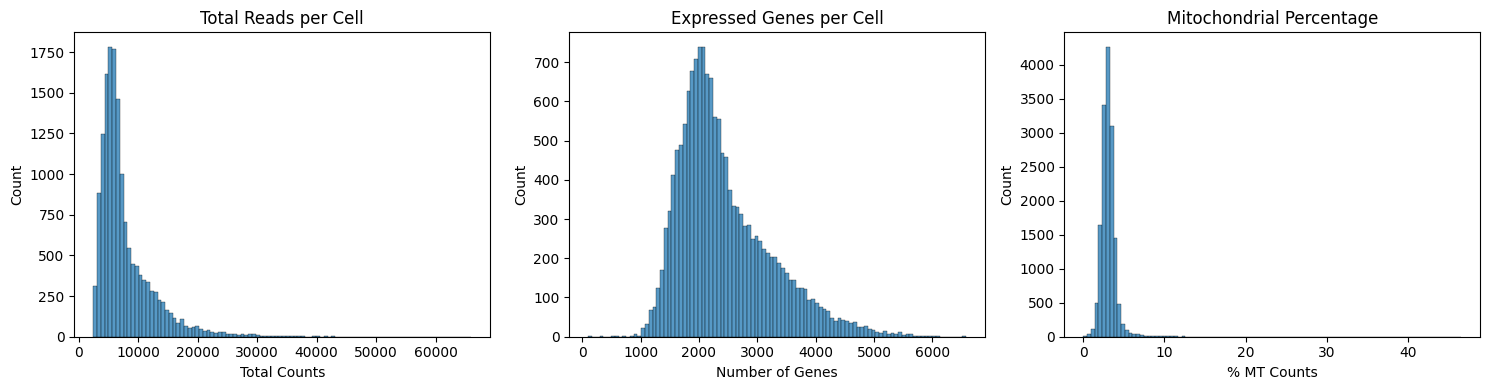

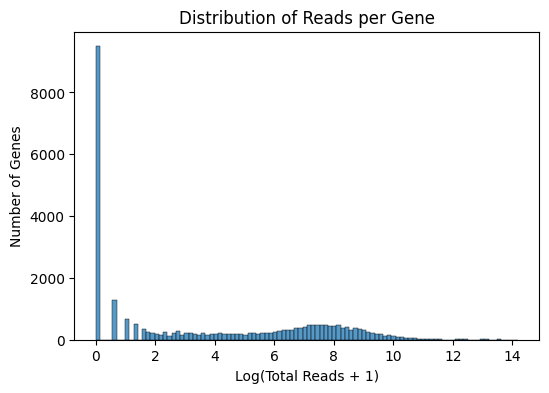

In [11]:
# Identify mitochondrial genes (adjust prefix 'MT-' to 'mt-' if using mouse data)
adata.var['mt'] = adata.var_names.str.startswith('mt-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Plot distributions across cells
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adata.obs['total_counts'], bins=100, ax=axs[0]).set(title='Total Reads per Cell', xlabel='Total Counts')
sns.histplot(adata.obs['n_genes_by_counts'], bins=100, ax=axs[1]).set(title='Expressed Genes per Cell', xlabel='Number of Genes')
sns.histplot(adata.obs['pct_counts_mt'], bins=100, ax=axs[2]).set(title='Mitochondrial Percentage', xlabel='% MT Counts')
plt.tight_layout()
plt.show()

# Show total reads across genes (how highly expressed each gene is across the dataset)
plt.figure(figsize=(6, 4))
sns.histplot(np.log1p(adata.var['total_counts']), bins=100)
plt.title('Distribution of Reads per Gene')
plt.xlabel('Log(Total Reads + 1)')
plt.ylabel('Number of Genes')
plt.show()

Notice that single cell data is typically very sparse: most genes are not expressed in most cells. We can visualize this by looking at how common are specific count values:

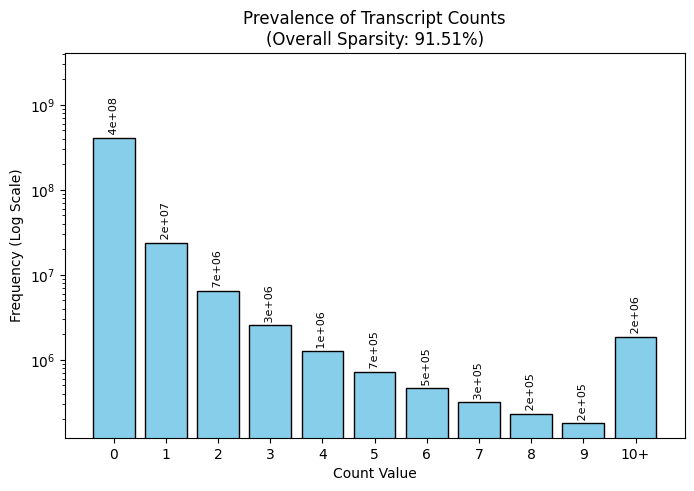

In [12]:
if sp.issparse(adata.X):
    # Calculate the total number of zeros
    total_elements = adata.shape[0] * adata.shape[1]
    non_zeros = adata.X.nnz
    num_zeros = total_elements - non_zeros
    
    # Get the counts of all non-zero values
    counts = adata.X.data
    non_zero_counts = np.bincount(counts.astype(int))
    
    # Combine zeros and non-zeros up to a count of 10
    max_plot_count = 10
    frequencies = np.concatenate([[num_zeros], non_zero_counts[1:max_plot_count]])
    
    # Pool everything > 10 into the last bin
    frequencies = np.append(frequencies, np.sum(non_zero_counts[max_plot_count:]))
    
    # Create labels
    x_labels = [str(i) for i in range(max_plot_count)] + [f'{max_plot_count}+']
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(x_labels, frequencies, color='skyblue', edgecolor='black')
    plt.yscale('log') # Log scale is necessary because zeros dwarf everything else
    plt.title(f'Prevalence of Transcript Counts\n(Overall Sparsity: {num_zeros/total_elements:.2%})')
    plt.xlabel('Count Value')
    plt.ylabel('Frequency (Log Scale)')
    
    for i, v in enumerate(frequencies):
        plt.text(i, v, f" {v:1.0e}", ha='center', va='bottom', fontsize=8, rotation=90)
        
    plt.ylim(top=max(frequencies) * 10) # Give room for labels
    plt.show()
else:
    print("Matrix is not sparse.")

*Assignment:* Convert the graph above to "normal" linear scale and observe the massive overabundance of zero expression measurements.

A lot of tutorials recommend filtering the dataset based on some pre-defined "reasonable" constant values:

In [13]:
adata_manual = adata.copy()
print(f"Cells before filtering: {adata_manual.n_obs}")
print(f"Genes before filtering: {adata_manual.n_vars}")

# 1. Filter Cells (Adjust thresholds based on your specific histograms from above!)
sc.pp.filter_cells(adata_manual, min_genes=200)
sc.pp.filter_cells(adata_manual, max_genes=5000)
sc.pp.filter_cells(adata_manual, min_counts=250)
sc.pp.filter_cells(adata_manual, max_counts=30000)
# Filter by MT percentage (typically < 5% or 10% depending on tissue)
adata_manual = adata_manual[adata_manual.obs['pct_counts_mt'] < 10, :].copy() 

# 2. Filter Genes
# Standard: Keep genes expressed in at least 3 cells
sc.pp.filter_genes(adata_manual, min_cells=3)

print(f"Cells after filtering: {adata_manual.n_obs}")
print(f"Genes after filtering: {adata_manual.n_vars}")

Cells before filtering: 15566
Genes before filtering: 28692


Cells after filtering: 15389
Genes after filtering: 17173


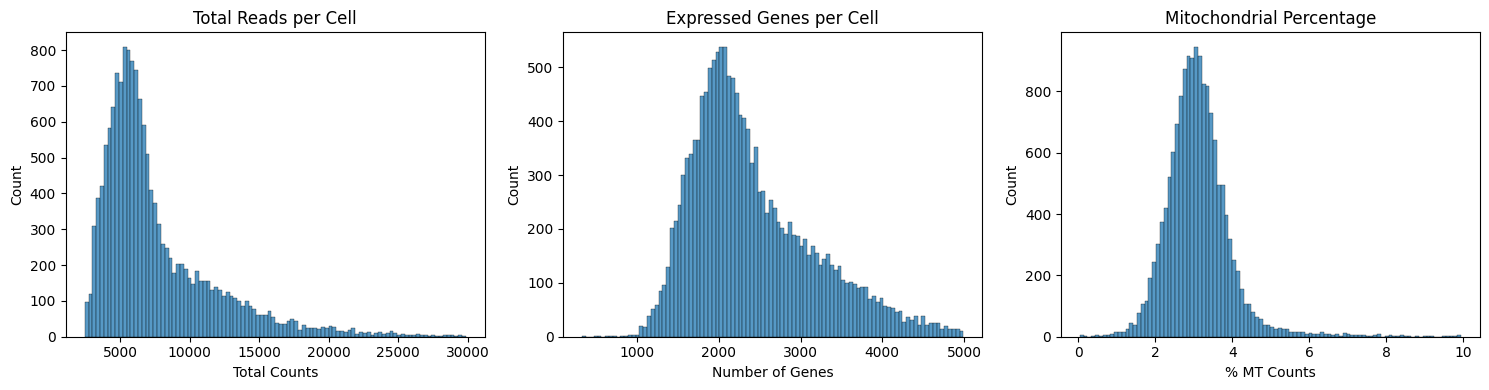

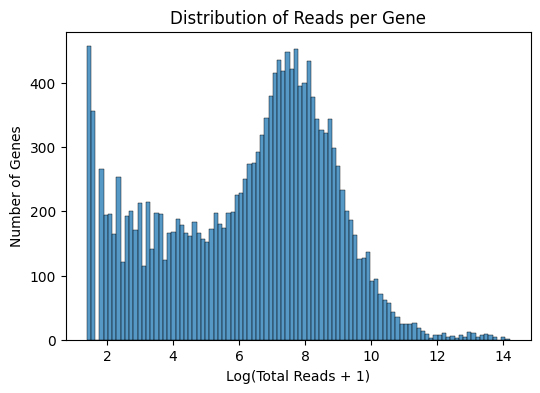

In [14]:
# Identify mitochondrial genes (adjust prefix 'MT-' to 'mt-' if using mouse data)
adata_manual.var['mt'] = adata_manual.var_names.str.startswith('mt-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_manual, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Plot distributions across cells
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adata_manual.obs['total_counts'], bins=100, ax=axs[0]).set(title='Total Reads per Cell', xlabel='Total Counts')
sns.histplot(adata_manual.obs['n_genes_by_counts'], bins=100, ax=axs[1]).set(title='Expressed Genes per Cell', xlabel='Number of Genes')
sns.histplot(adata_manual.obs['pct_counts_mt'], bins=100, ax=axs[2]).set(title='Mitochondrial Percentage', xlabel='% MT Counts')
plt.tight_layout()
plt.show()

# Show total reads across genes (how highly expressed each gene is across the dataset)
plt.figure(figsize=(6, 4))
sns.histplot(np.log1p(adata_manual.var['total_counts']), bins=100)
plt.title('Distribution of Reads per Gene')
plt.xlabel('Log(Total Reads + 1)')
plt.ylabel('Number of Genes')
plt.show()

This indeed looks better, but we may not get the same good results using these "magic constants" on every dataset. 

Therefore, you can also use some semi-automated methods that identify the outlier cutoff based on the properties of the data. One of such properties is [median absolute deviation](https://en.wikipedia.org/wiki/Median_absolute_deviation). This is what we will use today as our filtering step.

However, keep in mind that this technique must not be repeated on the same dataset (otherwise there is a chance we will always cut of "a bit more" of the data in each repetition).

Notably, this technique is not usually applied to filter genes. For gene filtering, we typically either use some minimum absolute number of counts (e.g., expressed in at least 3 cells), or we use some threshold relative to the size of our dataset (e.g., expressed in at least 5% of cells). Naturally, the first option preserves more genes, which may be good if we are trying to identify small cell populations in an otherwise large dataset. The second option typically preserves fewer genes, but is fine if we just want a "broad overview" of the dataset. If we already have some phenotype annotations, we can also do this filtering for each cell type separately, thus ensuring a gene is present if it is significantly active in at least one sub-population, even if that sub-population is very small.

In [15]:
def is_outlier(adata, metric: str, nmads: int, side: str = 'both'):
    """
    Identifies cell outliers based on Median Absolute Deviation (MAD).
    
    Parameters:
    - metric: The column in adata.obs to evaluate (e.g., 'total_counts')
    - nmads: Number of MADs away from median to threshold (usually 3 to 5)
    - side: 'both' (filters high and low), 'greater' (filters only high), 'less' (filters only low)
    """
    M = adata.obs[metric]
    median = np.median(M)
    mad = np.median(np.abs(M - median))
    
    # Scale MAD to act like a robust standard deviation
    # (1.4826 is a standard mathematical constant to align MAD with normal distributions)
    robust_std = 1.4826 * mad
    
    if side == 'both':
        return (M < median - nmads * robust_std) | (M > median + nmads * robust_std)
    elif side == 'greater':
        return M > median + nmads * robust_std
    elif side == 'less':
        return M < median - nmads * robust_std

print(f"Cells before filtering: {adata.n_obs}")

# 1. Flag outliers for counts and genes (both high and low ends)
# 5 MADs is a standard permissive threshold to keep as much viable data as possible
outlier_counts = is_outlier(adata, "total_counts", nmads=5, side='both')
outlier_genes = is_outlier(adata, "n_genes_by_counts", nmads=5, side='both')

# 2. Flag outliers for mitochondrial percentage (only on the high end)
# Cells with high MT are dying, but cells with 0% MT are perfectly fine!
outlier_mt = is_outlier(adata, "pct_counts_mt", nmads=3, side='greater')

# 3. Apply the filters (keep cells that are NOT outliers in any of the three categories)
is_keep = ~(outlier_counts | outlier_genes | outlier_mt)
adata = adata[is_keep, :].copy()

# 4. Filter genes expressed in fewer than 3 cells
sc.pp.filter_genes(adata, min_cells=3)

print(f"Cells after adaptive filtering: {adata.n_obs}")

Cells before filtering: 15566


Cells after adaptive filtering: 14637


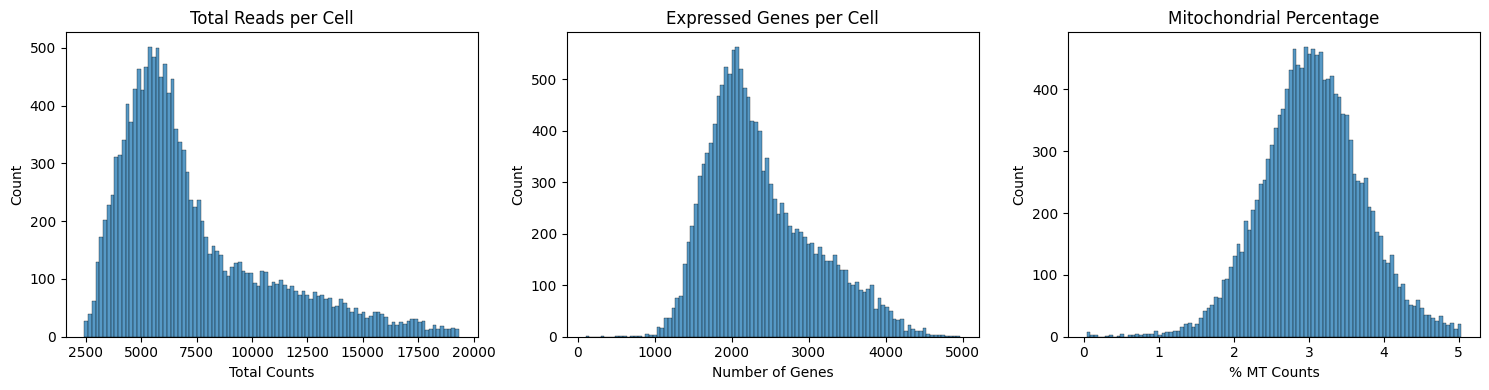

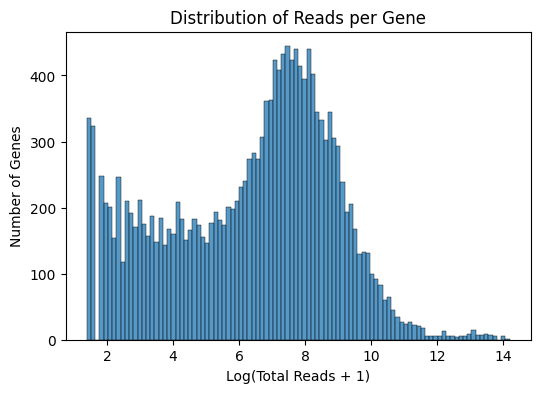

In [16]:

# Plot distributions across cells
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adata.obs['total_counts'], bins=100, ax=axs[0]).set(title='Total Reads per Cell', xlabel='Total Counts')
sns.histplot(adata.obs['n_genes_by_counts'], bins=100, ax=axs[1]).set(title='Expressed Genes per Cell', xlabel='Number of Genes')
sns.histplot(adata.obs['pct_counts_mt'], bins=100, ax=axs[2]).set(title='Mitochondrial Percentage', xlabel='% MT Counts')
plt.tight_layout()
plt.show()

# Show total reads across genes (how highly expressed each gene is across the dataset)
plt.figure(figsize=(6, 4))
sns.histplot(np.log1p(adata.var['total_counts']), bins=100)
plt.title('Distribution of Reads per Gene')
plt.xlabel('Log(Total Reads + 1)')
plt.ylabel('Number of Genes')
plt.show()

Note that even with these transformations, the dataset is still very sparse, meaning the high number of zeros in the matrix is not just due to the outlier cells and inactive genes.

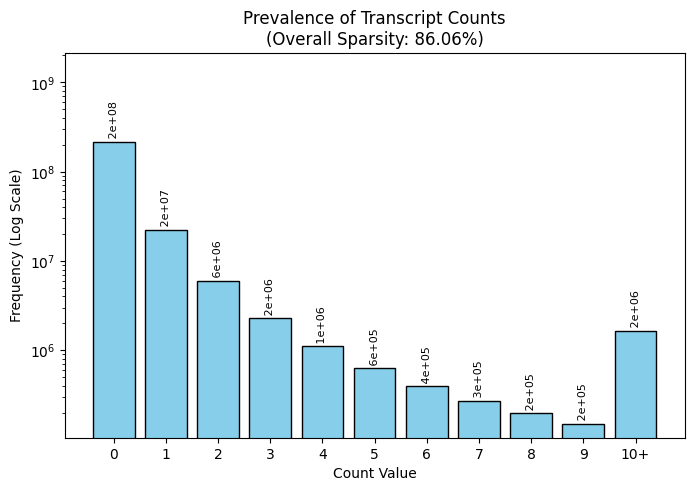

In [17]:
if sp.issparse(adata.X):
    # Calculate the total number of zeros
    total_elements = adata.shape[0] * adata.shape[1]
    non_zeros = adata.X.nnz
    num_zeros = total_elements - non_zeros
    
    # Get the counts of all non-zero values
    counts = adata.X.data
    non_zero_counts = np.bincount(counts.astype(int))
    
    # Combine zeros and non-zeros up to a count of 10
    max_plot_count = 10
    frequencies = np.concatenate([[num_zeros], non_zero_counts[1:max_plot_count]])
    
    # Pool everything > 10 into the last bin
    frequencies = np.append(frequencies, np.sum(non_zero_counts[max_plot_count:]))
    
    # Create labels
    x_labels = [str(i) for i in range(max_plot_count)] + [f'{max_plot_count}+']
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(x_labels, frequencies, color='skyblue', edgecolor='black')
    plt.yscale('log') # Log scale is necessary because zeros dwarf everything else
    plt.title(f'Prevalence of Transcript Counts\n(Overall Sparsity: {num_zeros/total_elements:.2%})')
    plt.xlabel('Count Value')
    plt.ylabel('Frequency (Log Scale)')
    
    for i, v in enumerate(frequencies):
        plt.text(i, v, f" {v:1.0e}", ha='center', va='bottom', fontsize=8, rotation=90)
        
    plt.ylim(top=max(frequencies) * 10) # Give room for labels
    plt.show()
else:
    print("Matrix is not sparse.")

In theory, this is all that we need to do for most GRN inference tools to function. As such, let us save this dataset for future analysis using a special `h5ad` AnnData file that preserves all the cell annotations.

In [18]:
adata.write_h5ad("data/filtered_counts.h5ad")

!mkdir -p data/filtered_counts

# ---- Save the matrix as .mtx ----
# If your matrix is dense, convert to sparse first
if not hasattr(adata.X, "toarray"):
    mtx = sp.csr_matrix(adata.X)
else:
    mtx = adata.X

# Transpose to genes × cells (10x convention) before writing
scipy.io.mmwrite("data/filtered_counts/matrix.mtx", mtx.T, field="integer" if "int" in str(adata.X.dtype) else "real")

# ---- Save barcodes (obs_names) ----
pd.Series(adata.obs_names).to_csv("data/filtered_counts/barcodes.tsv", sep="\t", index=False, header=False)

# ---- Save genes/features (var_names) ----
pd.Series(adata.var_names).to_csv("data/filtered_counts/genes.tsv", sep="\t", index=False, header=False)

## Appendix: other analysis and visualization

While the raw output of our quality control pipeline is typically enough to perform GRN inference, we can often do other types of analysis to understand our data better.

This typically involves (1) Normalizing the raw counts to minimize procedural differences between genes and between cells ("well sampled" cells have a lot of counts, "poorly sampled" cells have a lot of counts, etc.); (2) Computing highly variable genes; and (3) performing dimensionality reduction (often for visualization purposes, but sometimes as an initial step towards clustering).

As the first step, we normalize and scale the data, plus detect highly variable genes. However, just as with gene filtering previously, note that HVGs are useful to uncover broad trends, but filtering your GRN only to HVGs is often too restrictive. Genes with universally low expression can change significantly between populations but remain undetected by most common HVG selection settings.


/home/xpastva/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


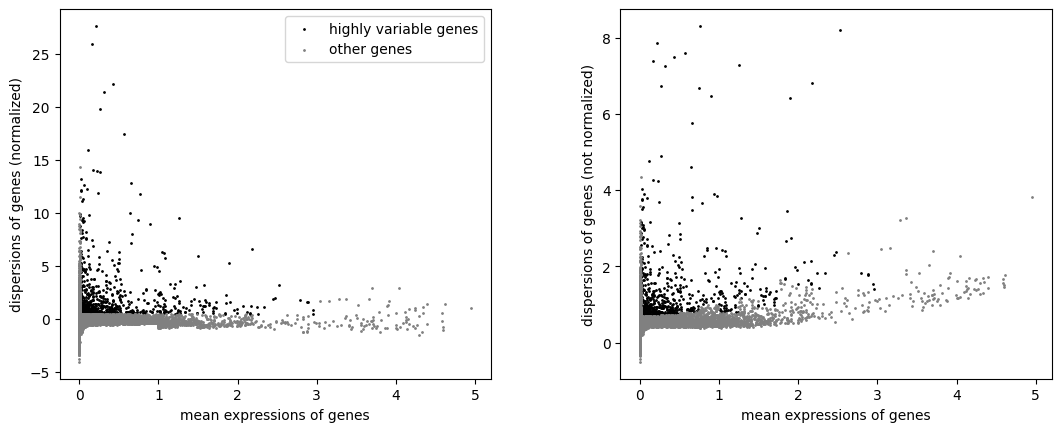

In [19]:
# Make a copy of the original adata object so that we can access it later if we need to.
adata_original = adata.copy()

# Save the raw counts in a separate layer, as some algorithms also need the raw data
adata.layers['counts'] = adata.X.copy()

# Normalize total counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)

# Find highly variable genes (HVGs) - this highlights genes driving biological variance
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

sc.pl.highly_variable_genes(adata)

We can also compute an UMAP dimensionality reduction and visualize it as a plot. However, be aware that these dimensionality reductions (UMAP, PCA, tSNE) are often very reductive, especially if we are only looking at a plot that shows two dimensions. They can be indicative of broader trends, but they are sensitive to visualization parameters, dataset noise, etc. In other words, they can be useful visualisation aides or in some cases, used as simplified representations of cells for clustering, but we must not forget that they can can amplify certain effects while erasing others.

In [20]:
# First, we run PCA to reduce all gene dimensions into a smaller continuous space.
sc.tl.pca(adata, svd_solver='arpack')

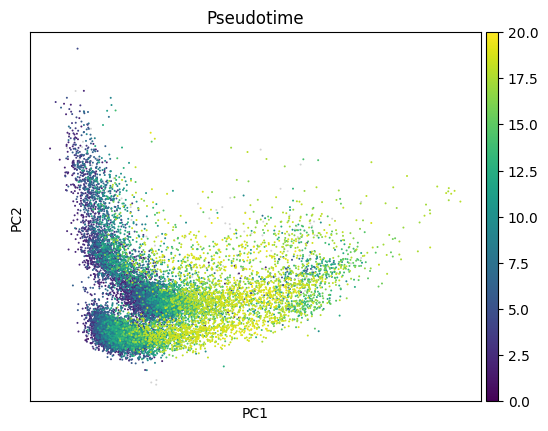

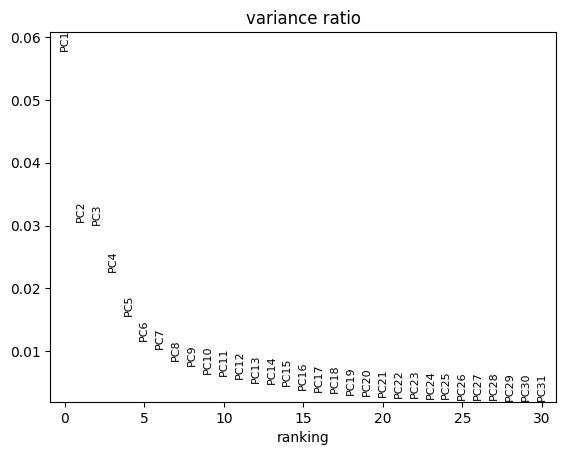

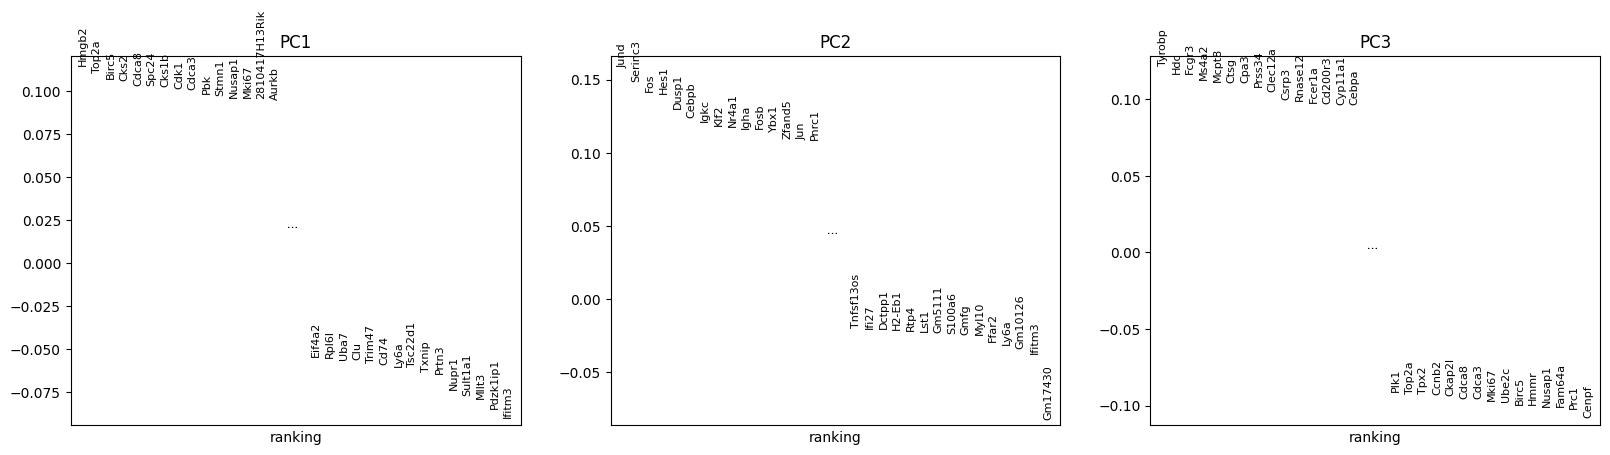

In [21]:
# Discussion question... what is PCA and how do we interpret these results?
sc.pl.pca(adata, color='Pseudotime')
sc.pl.pca_variance_ratio(adata, log=False)
sc.pl.pca_loadings(adata)

In [22]:
# Compute the neighborhood graph
# n_neighbors: Controls how the algorithm balances local vs. global structure. 
# n_pcs: Tells the algorithm how many Principal Components to use (typically 20-30).
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# Run UMAP
sc.tl.umap(adata)

/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


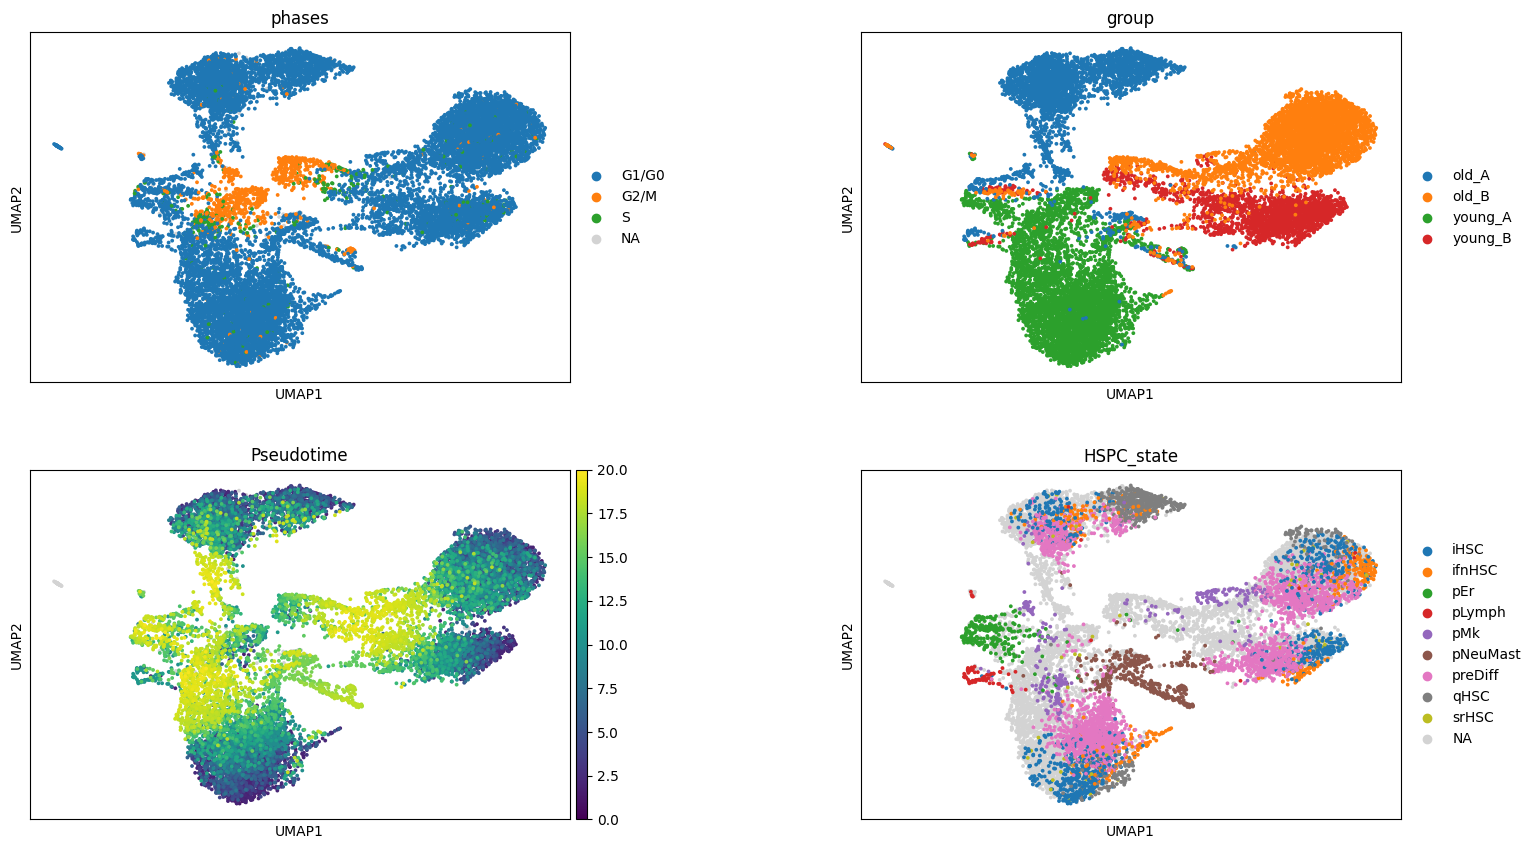

In [23]:

# Plot the UMAP
# We can color the plot using the cell metadata we loaded from our annotations!
sc.pl.umap(
    adata, 
    color=['phases', 'group', 'Pseudotime', 'HSPC_state'], 
    size=30, 
    ncols=2,       # Show 3 plots side-by-side
    wspace=0.4     # Add some horizontal space between the plots
)

There is an important pattern in both of these visualizations! The biggest contributor towards what cells are shown "together" does not seem to be their "function", but which group they were sequenced in.


This is a common problem which is called "batch effect", and is arises because each sequencing run is ultimately configured a little different (and subject to different noise conditions, etc.).

This is a big complication for analysis of large combined datasets, but we can try to mitigate it using *batch correction*.

This is again a very broad topic, with many tools and many discussions about what batch correction should preserve and how it should work. For today, we just show how to run one possible implementation and what effect it has on our data. Importanntly, most batch correction approaches only work on highly variable genes, because only for them there is enough information to recognize what is the "biological signal" and what is the "technical noise" that differentiates each dataset. As such, batch correction gives us an opportunity to merge multiple datasets, but it also, to some extend, loses resoulution in terms of lowly expressed genes.

In [24]:
# 1. Subset your AnnData to ONLY the highly variable genes we found earlier
# (This copy contains only the ~2,000 highly variable genes, bypassing zero-variance genes)
adata_corrected = adata[:, adata.var['highly_variable']].copy()

# 2. Run ComBat batch correction only on these highly variable genes
print("Running ComBat batch correction on highly variable genes...")
sc.pp.combat(adata_corrected, key='group')

# 3. Scale the ComBat-corrected counts
# (Note: We do NOT need to re-run highly_variable_genes, as we are already subsetted to them)
sc.pp.scale(adata_corrected, max_value=10)

Running ComBat batch correction on highly variable genes...


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


In [25]:

# Re-run PCA, Neighbors, and UMAP on the integrated data
sc.tl.pca(adata_corrected, svd_solver='arpack')
sc.pp.neighbors(adata_corrected, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_corrected)

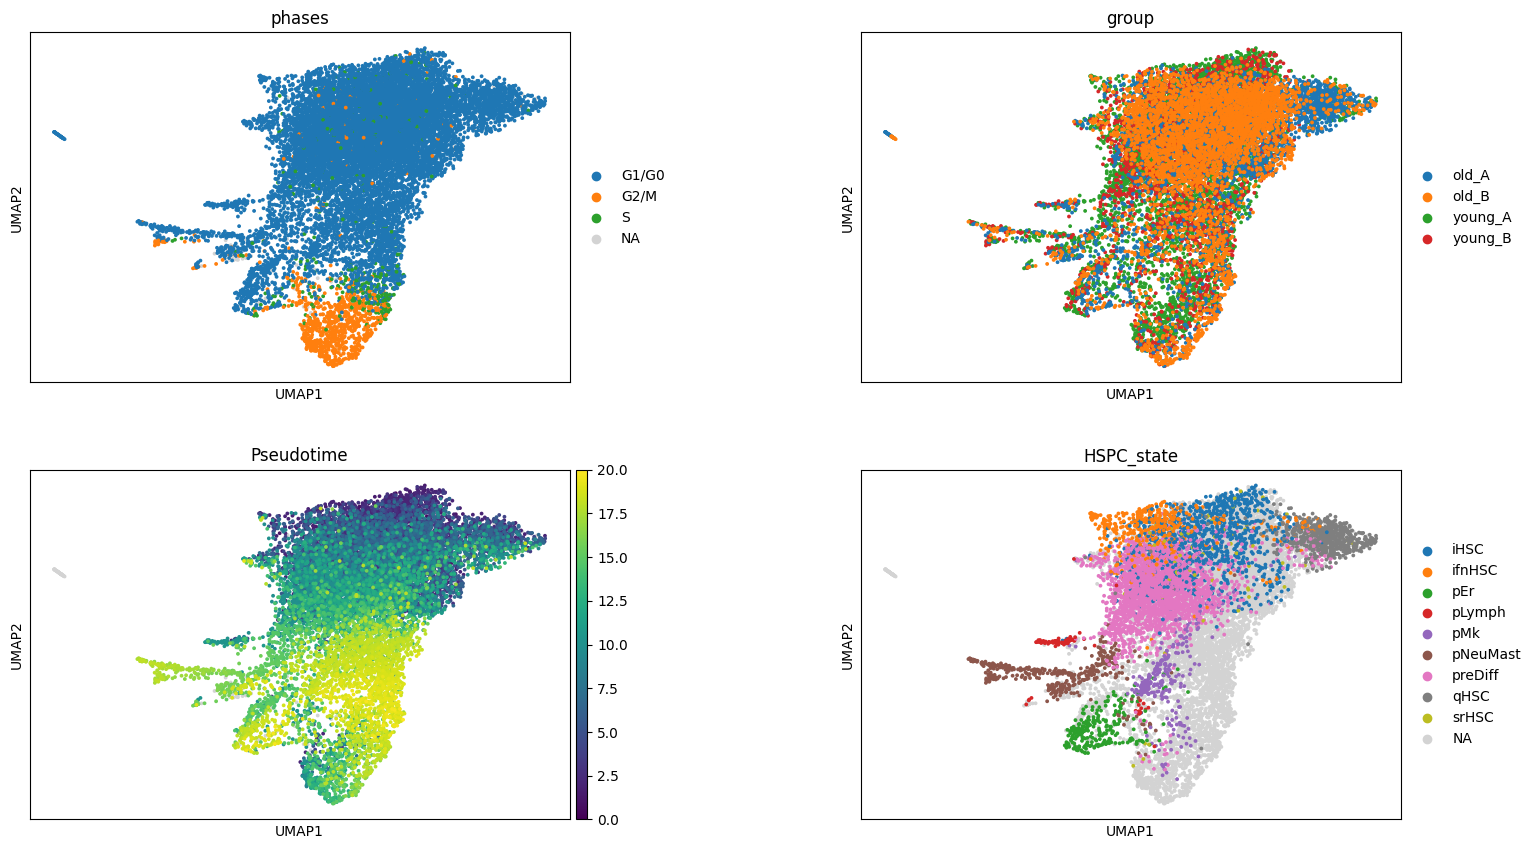

In [26]:
sc.pl.umap(
    adata_corrected, 
    color=['phases', 'group', 'Pseudotime', 'HSPC_state'], 
    size=30, 
    ncols=2,       # Show 3 plots side-by-side
    wspace=0.4     # Add some horizontal space between the plots
)

As we can see, the four groups now overlap in the visualization.

Let's draw one plot for each cell phenotype, to better identify where in the relation are they most prevalent:

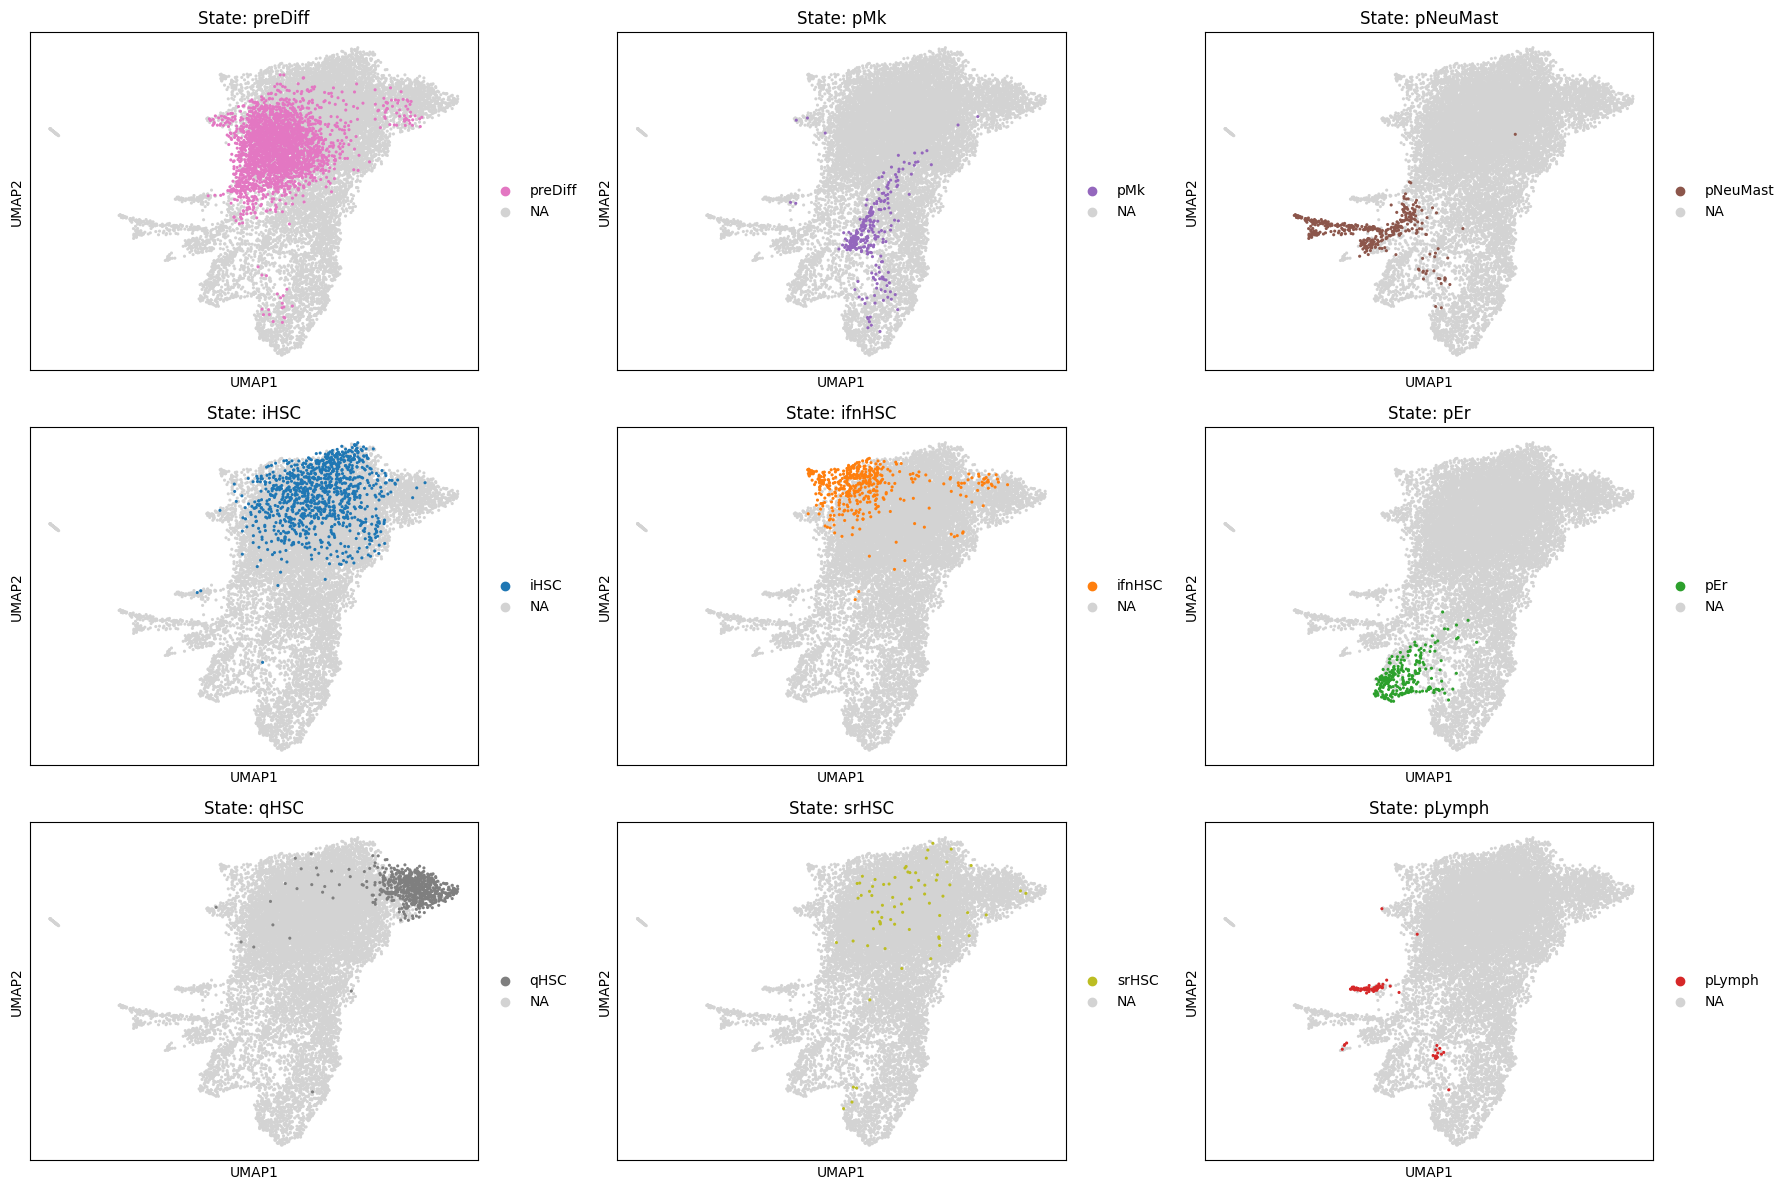

In [27]:
import matplotlib.pyplot as plt
import math

# 1. Get all unique HSPC states (excluding nulls and 'NA')
unique_states = [
    state for state in adata_corrected.obs['HSPC_state'].unique() 
    if pd.notna(state) and state != 'NA'
]

# 2. Define the grid layout (3 plots per row)
ncols = 3
nrows = math.ceil(len(unique_states) / ncols)

# Create the matplotlib figure
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 4 * 1.5, nrows * 4))

# Flatten the axes array to 1D so we can easily loop over it
# (Handle the case where there is only 1 state to prevent errors)
if len(unique_states) == 1:
    axs = [axs]
else:
    axs = axs.flatten()

# 3. Loop through each state and plot it on its assigned subplot
for i, state in enumerate(unique_states):
    sc.pl.umap(
        adata_corrected, 
        color='HSPC_state', 
        groups=[state],  # Highlight only this specific state
        ax=axs[i],       # Tell Scanpy to draw on this specific matplotlib axis
        show=False,      # Prevent the plot from rendering immediately
        size=20, 
        title=f"State: {state}"
    )

# 4. Hide any empty subplots in the grid 
# (e.g., if you have 5 states in a 3x2 grid, this hides the 6th empty box)
for j in range(len(unique_states), len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

Finally, lets look at the expression of individual genes across different cell phenotypes:

In [28]:
def plot_custom_violin(adata, obs_key, gene, values=None):
    """
    Plots a violin plot of a gene's expression across specified observation categories.
    
    Parameters:
    - adata: AnnData object (containing unscaled, log-normalized counts)
    - obs_key: The observation column to group by (e.g., 'HSPC_state')
    - gene: The gene of interest (string, e.g., 'Runx1')
    - values: List of categories to include. If None or empty, plots all non-NA categories.
    """
    # 1. Safety check: Verify the gene actually exists in the dataset
    if gene not in adata.var_names:
        print(f"Error: Gene '{gene}' was not found in this dataset. (Is it spelled correctly?)")
        return
    
    # 2. If no values list is provided, find all unique, non-NA values in the dataset
    if values is None or len(values) == 0:
        unique_vals = adata.obs[obs_key].dropna().unique()
        values_to_plot = [v for v in unique_vals if v != 'NA']
    else:
        values_to_plot = values
        
    # 3. Subset the AnnData object to keep only cells belonging to the requested categories
    # (We use .copy() to prevent Pandas/Scanpy setting-with-copy warnings)
    adata_subset = adata[adata.obs[obs_key].isin(values_to_plot)].copy()
    
    # 4. Draw the violin plot
    # use_raw=False forces Scanpy to read from adata_subset.X (our log-normalized counts)
    sc.pl.violin(
        adata_subset, 
        keys=gene, 
        groupby=obs_key, 
        use_raw=False, 
        rotation=45,
    )

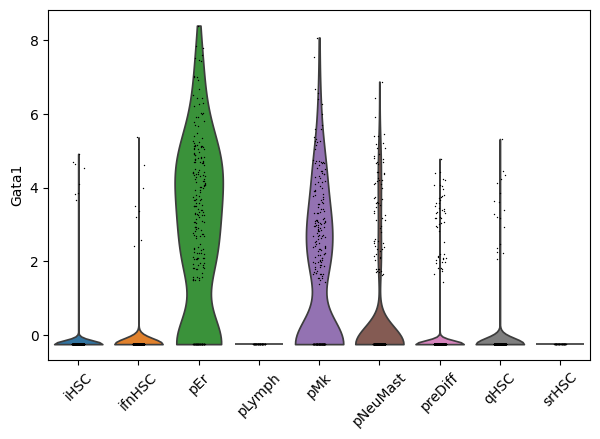

In [29]:
plot_custom_violin(
    adata=adata, 
    obs_key='HSPC_state', 
    gene='Gata1'
)

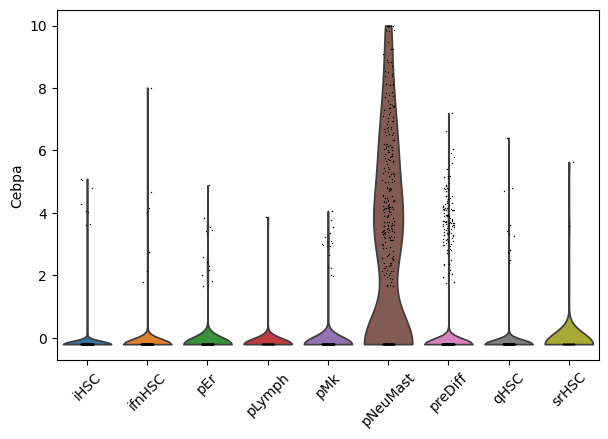

In [30]:
plot_custom_violin(
    adata=adata, 
    obs_key='HSPC_state', 
    gene='Cebpa'
)

As we can see, differen cell phenotypes have often very different expression of specific genes. For now, we will be satisfied with merely "seeing" that there is a difference. However, later in the course, we will explore how exactly this difference is measured and analyzed.